<a href="https://colab.research.google.com/github/Tanushri-07/bike-prediction-rental-ml-model/blob/main/bike_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo xgboost -q

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

bike = fetch_ucirepo(id=275)
df = bike.data.features.copy()
df['cnt'] = bike.data.targets.values
df['datetime'] = pd.to_datetime(df['dteday']) + pd.to_timedelta(df['hr'], unit='h')
df = df.sort_values('datetime').reset_index(drop=True)

print("Dataset shape:", df.shape)
print("\nMissing values:", df.isnull().sum().sum())
df.describe()

Dataset shape: (17379, 15)

Missing values: 0


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,datetime
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379
mean,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,189.463088,2012-01-02 15:41:22.858622464
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,1.000000,2011-01-01 00:00:00
25%,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,40.000000,2011-07-04 22:30:00
50%,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,142.000000,2012-01-02 21:00:00
75%,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,281.000000,2012-07-02 06:30:00
max,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,977.000000,2012-12-31 23:00:00
std,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,181.387599,NaN


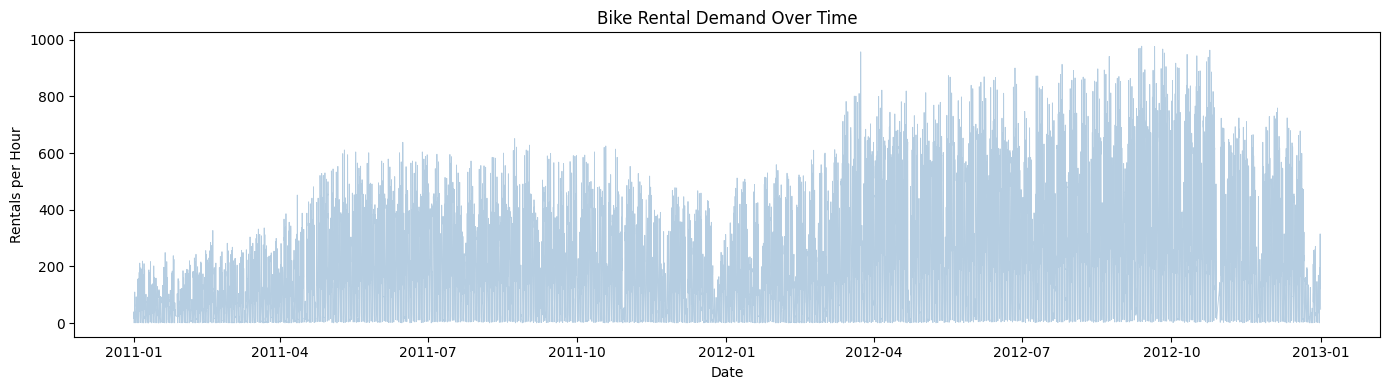


Observation:
- Overall demand is higher in 2012 vs 2011 → system is growing
- Clear seasonal dips in winter months



In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df['datetime'], df['cnt'], alpha=0.4, color='steelblue', linewidth=0.6)
plt.title('Bike Rental Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Rentals per Hour')
plt.tight_layout()
plt.show()

print("""
Observation:
- Overall demand is higher in 2012 vs 2011 → system is growing
- Clear seasonal dips in winter months
""")

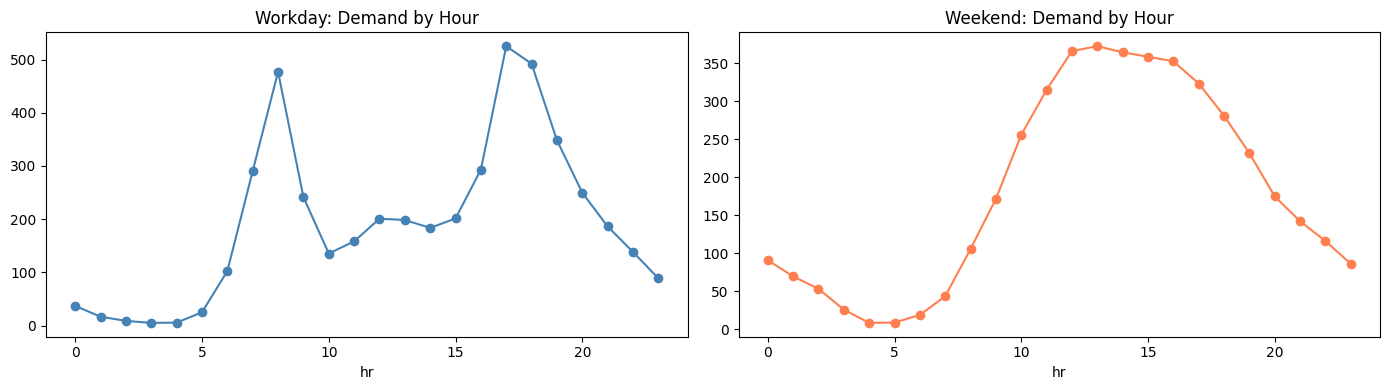


Observation:
- Workdays: Two peaks at 8AM and 5-6PM → commuters dominate
- Weekends: Single smooth peak around 1-3PM → leisure riders
- This tells us hour + workingday interaction is very important



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['workingday']==1].groupby('hr')['cnt'].mean().plot(
    ax=axes[0], title='Workday: Demand by Hour',
    color='steelblue', marker='o')

df[df['workingday']==0].groupby('hr')['cnt'].mean().plot(
    ax=axes[1], title='Weekend: Demand by Hour',
    color='coral', marker='o')

plt.tight_layout()
plt.show()

print("""
Observation:
- Workdays: Two peaks at 8AM and 5-6PM → commuters dominate
- Weekends: Single smooth peak around 1-3PM → leisure riders
- This tells us hour + workingday interaction is very important
""")

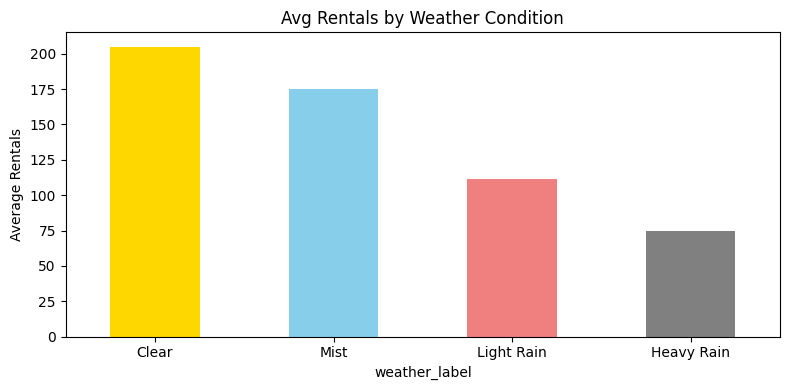


Observation:
- Clear weather = highest demand
- Heavy rain = almost no rentals
- Weather is a strong predictor



In [ ]:
weather_labels = {1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'}
df['weather_label'] = df['weathersit'].map(weather_labels)

df.groupby('weather_label')['cnt'].mean().sort_values(ascending=False).plot(
    kind='bar', color=['gold','skyblue','lightcoral','gray'],
    figsize=(8,4), title='Avg Rentals by Weather Condition')
plt.ylabel('Average Rentals')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
Observation:
- Clear weather = highest demand
- Heavy rain = almost no rentals
- Weather is a strong predictor
""")

<Figure size 1000x400 with 0 Axes>

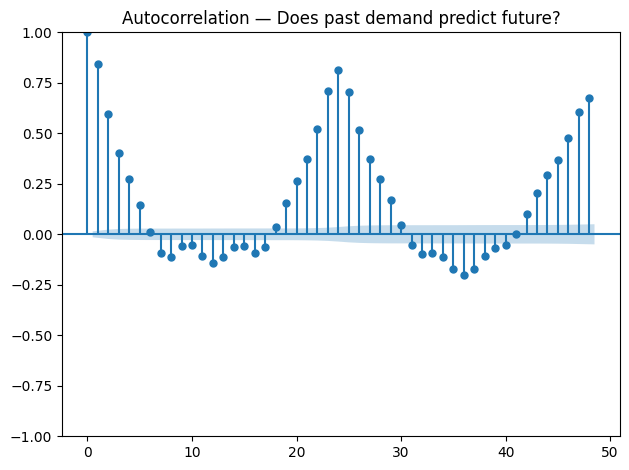


Observation:
- Strong spike at lag 1 → last hour predicts next hour
- Strong spike at lag 24 → same hour yesterday predicts today
- This justifies adding lag features



In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(10,4))
plot_acf(df['cnt'], lags=48)
plt.title('Autocorrelation — Does past demand predict future?')
plt.tight_layout()
plt.show()

print("""
Observation:
- Strong spike at lag 1 → last hour predicts next hour
- Strong spike at lag 24 → same hour yesterday predicts today
- This justifies adding lag features
""")

In [ ]:
def create_features(df):
    df = df.copy()

    # Basic time features
    df['hour']       = df['datetime'].dt.hour
    df['dayofweek']  = df['datetime'].dt.dayofweek
    df['month']      = df['datetime'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5,6]).astype(int)

    # Lag features — based on autocorrelation finding
    df['lag_1']      = df['cnt'].shift(1)   # last hour
    df['lag_24']     = df['cnt'].shift(24)  # same hour yesterday

    # Rolling average — smooth trend
    df['rolling_mean_24'] = df['cnt'].shift(1).rolling(24).mean()

    return df

df = create_features(df)
df = df.dropna().reset_index(drop=True)
print("Features created! Shape:", df.shape)

Features created! Shape: (17355, 23)


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Time-aware split (no shuffle!)
split = int(len(df) * 0.8)
train = df[:split]
test  = df[split:]

features = [
    'hour', 'dayofweek', 'month', 'is_weekend',
    'holiday', 'workingday', 'weathersit',
    'temp', 'hum', 'windspeed',
    'lag_1', 'lag_24', 'rolling_mean_24'
]

X_train, y_train = train[features], train['cnt']
X_test,  y_test  = test[features],  test['cnt']

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("✅ Model trained!")

✅ Model trained!


In [ ]:
pred = model.predict(X_test)
pred = np.clip(pred, 0, None)

mae  = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# Baseline = always predict average
base = np.full(len(y_test), y_train.mean())
base_mae  = mean_absolute_error(y_test, base)
base_rmse = np.sqrt(mean_squared_error(y_test, base))

print(f"{'Model':<15} {'MAE':>8} {'RMSE':>8}")
print(f"{'Baseline':<15} {base_mae:>8.2f} {base_rmse:>8.2f}")
print(f"{'Random Forest':<15} {mae:>8.2f} {rmse:>8.2f}")
print(f"\nImprovement: {(1-mae/base_mae)*100:.1f}% better than baseline")

Model                MAE     RMSE
Baseline          175.02   232.62
Random Forest      31.44    53.04

Improvement: 82.0% better than baseline


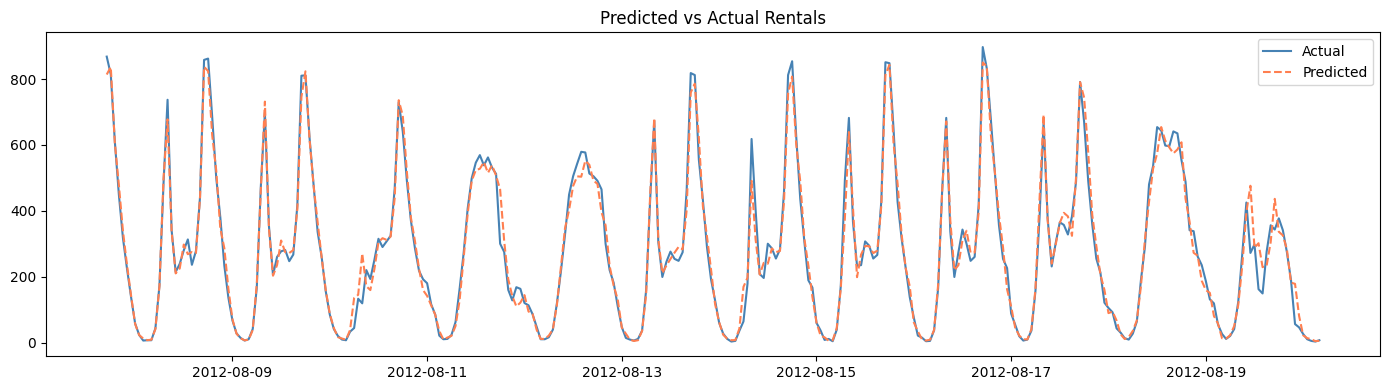

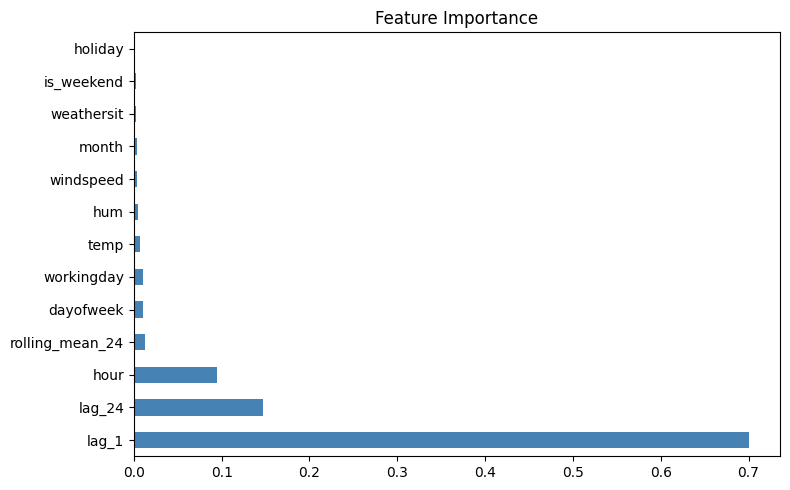

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(14,4))
plt.plot(test['datetime'].values[:300], y_test.values[:300], label='Actual', color='steelblue')
plt.plot(test['datetime'].values[:300], pred[:300], label='Predicted', color='coral', linestyle='--')
plt.title('Predicted vs Actual Rentals')
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
fi = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
fi.plot(kind='barh', figsize=(8,5), color='steelblue', title='Feature Importance')
plt.tight_layout()
plt.show()